# Detección de Primeros Fraudes en Tarjeta
Dataset: BO-VIP (Bolivia) | Modelo: LightGBM con métricas `feval` personalizadas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import lightgbm as lgb
import warnings
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (classification_report, roc_auc_score, ConfusionMatrixDisplay, RocCurveDisplay, precision_recall_curve)
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 80)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='whitegrid', palette='muted')

In [ ]:

DATA_PATH = r'Copia de Datasets 3 bancos/Copia de 01_bo_vip_seed22_n100000.csv'

---
## Carga y Parseo de Fechas

In [3]:
df = pd.read_csv(DATA_PATH, sep=';', low_memory=False)
print(f'Shape original: {df.shape}')
print(f'Columnas: {df.columns.tolist()}')

Shape original: (100003, 66)
Columnas: ['transaction_id', 'bank_code', 'bank_name', 'bank_country', 'bank_tier', 'client_id', 'client_segment', 'channel', 'card_brand', 'pan_masked', 'pan_hash', 'MTI', 'DE2_PAN', 'DE3_processing_code', 'DE4_amount_transaction', 'DE6_amount_cardholder_billing', 'DE7_transmission_datetime', 'DE9_conversion_rate_billing', 'DE11_STAN', 'DE12_local_time', 'DE13_local_date', 'DE14_expiration_date', 'DE15_settlement_date', 'DE18_merchant_category_code', 'DE19_acquirer_country_code', 'DE22_pos_entry_mode', 'DE23_card_seq_number', 'DE25_pos_condition_code', 'DE32_acquiring_institution_id', 'DE35_track2_data_masked', 'DE37_retrieval_reference_number', 'DE38_authorization_code', 'DE39_response_code', 'DE41_terminal_id', 'DE42_card_acceptor_id', 'DE43_card_acceptor_name_location', 'DE44_additional_response_data', 'DE48_additional_data', 'DE49_currency_code_transaction', 'DE50_currency_code_settlement', 'DE51_currency_code_billing', 'DE52_pin_data_present', 'DE54_a

In [4]:
# DE13_local_date está en formato MMDD (ej: 1231 = diciembre 31)
# DE12_local_time está en formato HHMMSS (ej: 200151 = 20:01:51)
df['local_month'] = (df['DE13_local_date'] // 100).astype(int)
df['local_day']   = (df['DE13_local_date'] % 100).astype(int)

# Diciembre 2024 aparece como mes 12 (transacciones que localmente son 31-dic-2024)
df['year'] = np.where(df['local_month'] == 12, 2024, 2025)

# Reconstruir timestamp completo
time_str = (df['DE12_local_time'].astype(int).astype(str)
              .str.zfill(6))
df['tx_datetime'] = pd.to_datetime(
    df['year'].astype(str) +
    df['local_month'].astype(str).str.zfill(2) +
    df['local_day'].astype(str).str.zfill(2) + ' ' +
    time_str.str[:2] + ':' + time_str.str[2:4] + ':' + time_str.str[4:],
    format='%Y%m%d %H:%M:%S',
    errors='coerce'
)

print(f'Nulls en tx_datetime: {df["tx_datetime"].isna().sum()}')
print(f'Rango de fechas: {df["tx_datetime"].min()} → {df["tx_datetime"].max()}')
print(f'\nTransacciones por mes:')
print(df['local_month'].value_counts().sort_index())

Nulls en tx_datetime: 0
Rango de fechas: 2024-12-31 20:01:51 → 2025-06-29 20:13:36

Transacciones por mes:
local_month
1     17230
2     15664
3     17133
4     16610
5     17199
6     16073
12       94
Name: count, dtype: int64


In [5]:
# Orden cronológicamente
df = df.sort_values('tx_datetime').reset_index(drop=True)
print(f'Dataset ordenado. Primeras fechas:')
print(df[['tx_datetime', 'client_id', 'amount_usd', 'is_fraud']].head(5))

Dataset ordenado. Primeras fechas:
          tx_datetime           client_id  amount_usd  is_fraud
0 2024-12-31 20:01:51  BO-VIP-CL-00001325    500.1200     False
1 2024-12-31 20:03:55  BO-VIP-CL-00000079   1898.9300     False
2 2024-12-31 20:04:10  BO-VIP-CL-00002344    349.8500     False
3 2024-12-31 20:04:53  BO-VIP-CL-00002587    345.5800     False
4 2024-12-31 20:07:56  BO-VIP-CL-00000087    118.9000     False


---
## EDA

Distribución Temporal y Primeros Fraudes

Total transacciones: 100,003
Fraudes: 4,919 (4.92%)


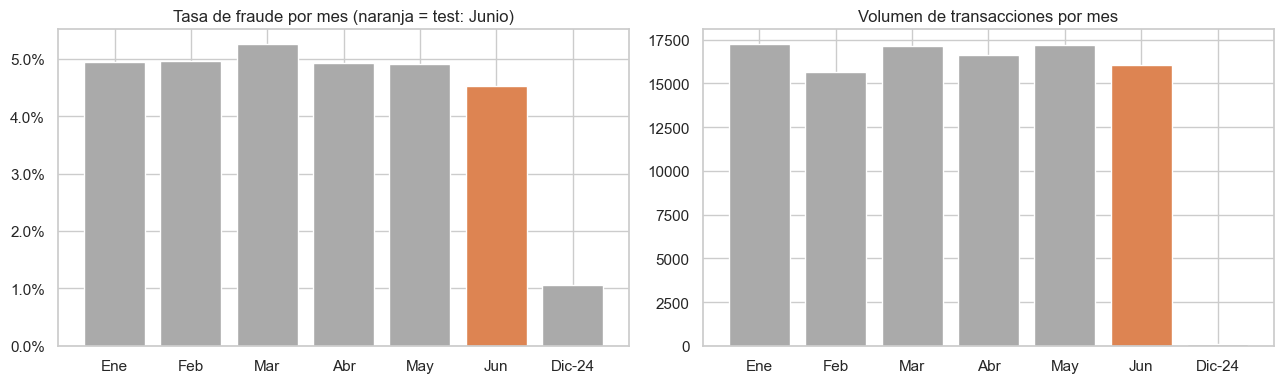

In [ ]:
# Distribución de fraude
fraud_rate = df['is_fraud'].mean()
print(f'Total transacciones: {len(df):,}')
print(f'Fraudes: {df["is_fraud"].sum():,} ({fraud_rate:.2%})')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

month_labels = {12: 'Dic-24', 1: 'Ene', 2: 'Feb', 3: 'Mar', 4: 'Abr', 5: 'May', 6: 'Jun'}
fraud_by_month = df.groupby('local_month')['is_fraud'].mean()
idx = fraud_by_month.index.tolist()
axes[0].bar(range(len(idx)), fraud_by_month.values, color=['#aaa' if m != 6 else '#dd8452' for m in idx])
axes[0].set_xticks(range(len(idx)))
axes[0].set_xticklabels([month_labels.get(m, str(m)) for m in idx])
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
axes[0].set_title('Tasa de fraude por mes (naranja = test: Junio)')

vol_by_month = df.groupby('local_month').size()
axes[1].bar(range(len(vol_by_month)), vol_by_month.values,
            color=['#aaa' if m != 6 else '#dd8452' for m in vol_by_month.index])
axes[1].set_xticks(range(len(vol_by_month)))
axes[1].set_xticklabels([month_labels.get(m, str(m)) for m in vol_by_month.index])
axes[1].set_title('Volumen de transacciones por mes')

plt.tight_layout()
plt.show()

Tarjetas con al menos un fraude: 1,520

Distribución de en qué # de transacción ocurre el primer fraude:
count   1520.0000
mean      11.8178
std        7.4640
min        1.0000
25%        6.0000
50%       11.0000
75%       17.0000
max       40.0000
Name: card_txn_number, dtype: float64


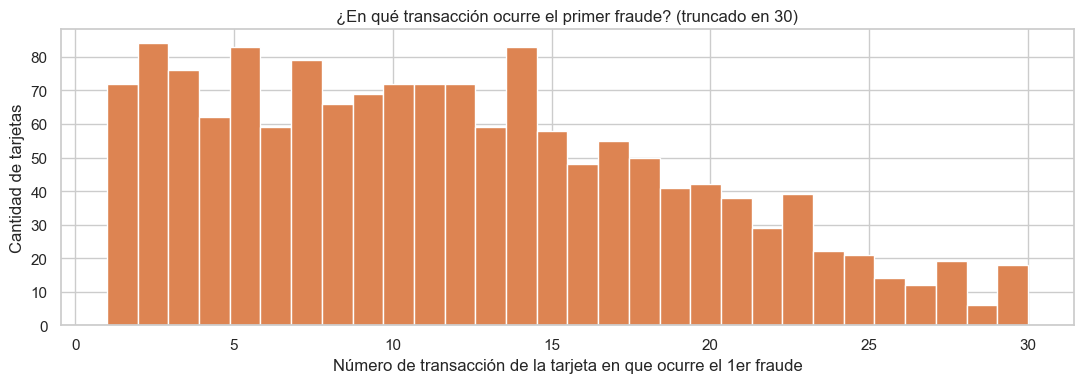

In [8]:
# Analizamos en qué transacción de la tarjeta ocurre el primer fraude
# identifiacar cada transacción por pan_hash (tarjeta) en orden temporal
df['card_txn_number'] = df.groupby('pan_hash').cumcount() + 1

# Identificar el PRIMER fraude de cada tarjeta
fraud_txns = df[df['is_fraud'] == True].copy()
first_fraud_per_card = fraud_txns.groupby('pan_hash')['card_txn_number'].min()

print(f'Tarjetas con al menos un fraude: {len(first_fraud_per_card):,}')
print(f'\nDistribución de en qué # de transacción ocurre el primer fraude:')
print(first_fraud_per_card.describe())

fig, ax = plt.subplots(figsize=(11, 4))
ax.hist(first_fraud_per_card.clip(upper=30), bins=30, color='#dd8452', edgecolor='white')
ax.set_xlabel('Número de transacción de la tarjeta en que ocurre el 1er fraude')
ax.set_ylabel('Cantidad de tarjetas')
ax.set_title('¿En qué transacción ocurre el primer fraude? (truncado en 30)')
plt.tight_layout()
plt.show()


In [14]:
pct_early = (first_fraud_per_card <= 5).mean()
print(f'{pct_early:.1%}')

pct_first = (first_fraud_per_card <= 1).mean()
print(f'{pct_first:.1%}')

24.8%
4.7%


24.8% de los primeros fraudes ocurren en las primeras 5 transacciones de la tarjeta y 4.7% del primer fraude ocurren en la PRIMERA transacción. 

---
## Feature Engineering Temporal

Features de velocidad y comportamiento del cliente a lo largo del tiempo

**minutos desde la transacción anterior del cliente**

In [15]:
df['prev_tx_datetime'] = df.groupby('client_id')['tx_datetime'].shift(1)
df['time_since_last_txn_min'] = (
    (df['tx_datetime'] - df['prev_tx_datetime']).dt.total_seconds() / 60
)
# Primera transacción del cliente → -1 (sin historial)
df['time_since_last_txn_min'] = df['time_since_last_txn_min'].fillna(-1)

print('time_since_last_txn_min:')
print(df[df['time_since_last_txn_min'] >= 0]['time_since_last_txn_min'].describe())

time_since_last_txn_min:
count    96003.0000
mean      9921.0914
std      10172.4451
min          0.1667
25%       2643.8667
50%       6854.0500
75%      13920.2167
max     126570.5167
Name: time_since_last_txn_min, dtype: float64


 txn_count_last_1h y txn_count_last_24h por cliente


In [17]:
# merge-asof sobre ventanas temporales
def count_in_window(df, client_col, time_col, window_minutes):
    """Para cada fila, cuenta cuántas transacciones tuvo el cliente
    en los `window_minutes` minutos anteriores (sin incluir la actual)."""
    results = np.zeros(len(df), dtype=int)
    df_sorted = df[[client_col, time_col]].copy()
    
    for client_id, grp in df_sorted.groupby(client_col):
        times = grp[time_col].values
        idx   = grp.index.values
        window_ns = np.timedelta64(window_minutes, 'm')
        for i, (t, ix) in enumerate(zip(times, idx)):
            # contar transacciones anteriores dentro de la ventana
            cutoff = t - window_ns
            count = np.sum((times[:i] >= cutoff) & (times[:i] < t))
            results[ix] = count
    return results

df['txn_count_last_1h']  = count_in_window(df, 'client_id', 'tx_datetime', 60)
df['txn_count_last_24h'] = count_in_window(df, 'client_id', 'tx_datetime', 1440)

print('\nDistribución txn_count_last_1h (fraude vs legítima):')
print(df.groupby('is_fraud')[['txn_count_last_1h', 'txn_count_last_24h']].mean())


Distribución txn_count_last_1h (fraude vs legítima):
          txn_count_last_1h  txn_count_last_24h
is_fraud                                       
False                0.0064              0.1388
True                 1.0378              1.6243


**z-score del monto vs historial PREVIO del cliente**

In [18]:
# Usar expanding() para no incluir datos futuros (sin data leakage)
df['client_expanding_mean'] = (
    df.groupby('client_id')['amount_usd']
      .transform(lambda x: x.expanding().mean().shift(1))
)
df['client_expanding_std'] = (
    df.groupby('client_id')['amount_usd']
      .transform(lambda x: x.expanding().std().shift(1))
)
df['amount_zscore_customer'] = (
    (df['amount_usd'] - df['client_expanding_mean'])
    / (df['client_expanding_std'].fillna(1) + 1e-6)
)
df['amount_zscore_customer'] = df['amount_zscore_customer'].fillna(0)

print('amount_zscore_customer por clase:')
print(df.groupby('is_fraud')['amount_zscore_customer'].describe().T)

amount_zscore_customer por clase:
is_fraud       False      True 
count     95084.0000  4919.0000
mean          0.9687    10.0099
std         198.3429   139.2113
min      -38451.9786 -2362.6276
25%          -0.6831    -0.1690
50%          -0.3804     0.9522
75%           0.2728     2.6099
max       11547.0218  3857.8861


---
## Features de Detección de Primeros Fraudes en Tarjeta

**Número de transacción del cliente y de la tarjeta**

In [20]:
df['client_txn_number'] = df.groupby('client_id').cumcount() + 1
df['client_txn_number']

0          1
1          1
2          1
3          1
4          1
          ..
99998     30
99999     26
100000    14
100001    25
100002    24
Name: client_txn_number, Length: 100003, dtype: int64

**Flags de primeras transacciones**

In [25]:
df['is_first_card_txn'] = (df['card_txn_number'] == 1).astype(int)
df['is_early_card_txn'] = (df['card_txn_number'] <= 5).astype(int)
df['is_new_client'] = (df['client_txn_number'] <= 3).astype(int)
df['is_new_client']

0         1
1         1
2         1
3         1
4         1
         ..
99998     0
99999     0
100000    0
100001    0
100002    0
Name: is_new_client, Length: 100003, dtype: int64

**Días desde la primera transacción de esta tarjeta**

In [26]:
card_first_txn = df.groupby('pan_hash')['tx_datetime'].transform('min')
# 86400 son los segundos en 24 h
df['card_age_days'] = (df['tx_datetime'] - card_first_txn).dt.total_seconds() / 86400
df['card_age_days']

0          0.0000
1          0.0000
2          0.0000
3          0.0000
4          0.0000
           ...   
99998    171.2801
99999    177.0714
100000   168.8899
100001   176.2888
100002   178.0348
Name: card_age_days, Length: 100003, dtype: float64

**Monto relativo al promedio de la tarjeta**

In [27]:
df['card_expanding_mean'] = (
    df.groupby('pan_hash')['amount_usd']
      .transform(lambda x: x.expanding().mean().shift(1))
)
df['amount_vs_card_avg'] = (
    df['amount_usd'] / (df['card_expanding_mean'].fillna(df['amount_usd']) + 1e-6)
)

# Verificación
print('Tasa de fraude por tramo de card_txn_number:')
df['card_txn_bucket'] = pd.cut(df['card_txn_number'], [0,1,3,5,10,20,50,1000],
                                labels=['1','2-3','4-5','6-10','11-20','21-50','51+'])
print(df.groupby('card_txn_bucket', observed=True)['is_fraud'].agg(['mean','count'])
        .rename(columns={'mean':'fraud_rate','count':'n_tx'}))

Tasa de fraude por tramo de card_txn_number:
                 fraud_rate   n_tx
card_txn_bucket                   
1                    0.0180   4000
2-3                  0.0330   8000
4-5                  0.0441   8000
6-10                 0.0492  19999
11-20                0.0516  38325
21-50                0.0586  21679


**Canal, monto, ubicación del resto de fraudes**

In [30]:
df['is_weekend'] = df['day_of_week'].isin(['Sat', 'Sun']).astype(int)
df['is_night'] = df['hour_local'].between(0, 5).astype(int)
df['hour_sin'] = np.sin(2 * np.pi * df['hour_local'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour_local'] / 24)

df['is_online'] = df['DE22_pos_entry_mode'].isin([81, '81', '081']).astype(int)
df['is_cnp'] = ( df['DE22_pos_entry_mode'].isin([81, 10, '81', '010', '081']) | df['DE25_pos_condition_code'].isin([59, '59']) ).astype(int)
df['pin_used'] = (df['DE52_pin_data_present'].astype(str).str.upper() == 'Y').astype(int)
df['emv_used'] = (df['DE55_emv_data_present'].astype(str).str.upper() == 'Y').astype(int)

df['is_international'] = df['is_international'].astype(int)
df['distance_log'] = np.log1p(df['distance_from_home_km'].fillna(0))
df['high_distance'] = (df['distance_from_home_km'].fillna(0) > 500).astype(int)

df['amount_usd_log'] = np.log1p(df['amount_usd'])
df['amount_ratio_baseline'] = df['amount_usd'] / (df['client_baseline_amount'] + 1)

df['has_conversion'] = (df['DE9_conversion_rate_billing'] != 1.0).astype(int)
df['tx_declined'] = (df['DE39_response_code'] != '00').astype(int)
df['approved_int'] = df['approved'].astype(bool).astype(int)

HIGH_RISK_MCC = {5967, 6051, 7995, 5969, 4816, 5944}
df['mcc_high_risk'] = df['DE18_merchant_category_code'].isin(HIGH_RISK_MCC).astype(int)

print('Features construidas correctamente.')
df.shape

Features construidas correctamente.


(100003, 102)

**Codificación de variables categóricas**

In [ ]:
CAT_ENCODE = ['bank_tier', 'client_segment', 'channel', 'card_brand', 'DE22_pos_entry_mode', 'DE25_pos_condition_code', 
              'DE39_response_code', 'DE49_currency_code_transaction', 'currency_tx_alpha', 'DE60_pos_terminal_type']

label_encoders = {}
for col in CAT_ENCODE:
    if col in df.columns:
        le = LabelEncoder()
        df[col + '_enc'] = le.fit_transform(df[col].fillna('UNKNOWN').astype(str))
        label_encoders[col] = le

print('Categóricas codificadas:', [c for c in CAT_ENCODE if c in df.columns])

Categóricas codificadas: ['bank_tier', 'client_segment', 'channel', 'card_brand', 'DE22_pos_entry_mode', 'DE25_pos_condition_code', 'DE39_response_code', 'DE49_currency_code_transaction', 'currency_tx_alpha', 'DE60_pos_terminal_type']


In [39]:
df['DE25_pos_condition_code'].unique()

array([ 0, 59,  1,  8])

---
## Train Enero a Mayo - Test Junio

In [40]:
FEATURES = [
    # Temporales / velocidad
    'hour_local', 'hour_sin', 'hour_cos', 'is_weekend', 'is_night',
    'local_month',
    'time_since_last_txn_min',
    'txn_count_last_1h', 'txn_count_last_24h',

    # Primera transacción / tarjeta nueva
    'card_txn_number', 'client_txn_number',
    'is_first_card_txn', 'is_early_card_txn', 'is_new_client',
    'card_age_days',

    # Montos
    'amount_usd_log', 'amount_ratio_baseline',
    'amount_zscore_customer', 'amount_vs_card_avg',

    # Canal / POS
    'is_online', 'is_cnp', 'pin_used', 'emv_used',

    # Ubicación
    'is_international', 'distance_log', 'high_distance',

    # Riesgo MCC / respuesta
    'mcc_high_risk', 'has_conversion', 'tx_declined', 'approved_int',

    # Categóricas codificadas
    'bank_tier_enc', 'client_segment_enc', 'channel_enc', 'card_brand_enc',
    'DE22_pos_entry_mode_enc', 'DE25_pos_condition_code_enc',
    'DE39_response_code_enc', 'DE49_currency_code_transaction_enc',
    'currency_tx_alpha_enc', 'DE60_pos_terminal_type_enc', ]

In [42]:
FEATURES = [f for f in FEATURES if f in df.columns]
TARGET = 'is_fraud'

# junio como test
mask_test  = df['local_month'] == 6
mask_train = df['local_month'].isin([1, 2, 3, 4, 5])

df_train_split = df[mask_train]
df_test_split  = df[mask_test]

X_train = df_train_split[FEATURES]
y_train = df_train_split[TARGET].astype(int)
X_test  = df_test_split[FEATURES]
y_test  = df_test_split[TARGET].astype(int)

# Verificar no hay strings
bad = X_train.select_dtypes(include=['object','bool']).columns.tolist()
assert len(bad) == 0, f'Columnas no numéricas: {bad}'

print(f'Train: {X_train.shape} - Fraude rate: {y_train.mean():.2%}')
print(f'Test:  {X_test.shape} - Fraude rate: {y_test.mean():.2%}')
print(FEATURES)

Train: (83836, 40) - Fraude rate: 5.00%
Test:  (16073, 40) - Fraude rate: 4.52%
['hour_local', 'hour_sin', 'hour_cos', 'is_weekend', 'is_night', 'local_month', 'time_since_last_txn_min', 'txn_count_last_1h', 'txn_count_last_24h', 'card_txn_number', 'client_txn_number', 'is_first_card_txn', 'is_early_card_txn', 'is_new_client', 'card_age_days', 'amount_usd_log', 'amount_ratio_baseline', 'amount_zscore_customer', 'amount_vs_card_avg', 'is_online', 'is_cnp', 'pin_used', 'emv_used', 'is_international', 'distance_log', 'high_distance', 'mcc_high_risk', 'has_conversion', 'tx_declined', 'approved_int', 'bank_tier_enc', 'client_segment_enc', 'channel_enc', 'card_brand_enc', 'DE22_pos_entry_mode_enc', 'DE25_pos_condition_code_enc', 'DE39_response_code_enc', 'DE49_currency_code_transaction_enc', 'currency_tx_alpha_enc', 'DE60_pos_terminal_type_enc']


---
## 6. Modelo Base LightGBM (AUC-ROC y F1)

In [43]:
from sklearn.model_selection import train_test_split

In [44]:
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.15, random_state=42, stratify=y_train
)

LightGBM

In [45]:
dtrain = lgb.Dataset(X_tr, label=y_tr, feature_name=FEATURES)
dval   = lgb.Dataset(X_val, label=y_val, feature_name=FEATURES, reference=dtrain)

# Peso de clases para dataset desbalanceado
scale_pos = (y_tr == 0).sum() / (y_tr == 1).sum()

In [48]:
params_base = {
    'objective':        'binary',
    'metric':           'auc',
    'scale_pos_weight': scale_pos,
    'learning_rate':    0.05,
    'num_leaves':       63,
    'max_depth':        -1,
    'min_child_samples': 20,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq':     5,
    'verbose':          -1,
    'random_state':     42,
}

model_base = lgb.train(
    params_base,
    dtrain,
    num_boost_round=500,
    valid_sets=[dval],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(100)]
)

print(f'Mejor iteración: {model_base.best_iteration}')

[100]	valid_0's auc: 0.923155
Mejor iteración: 108


**Evaluación con test**

In [49]:
y_proba_base = model_base.predict(X_test)

In [50]:
precision_arr, recall_arr, thresholds_arr = precision_recall_curve(y_test, y_proba_base)

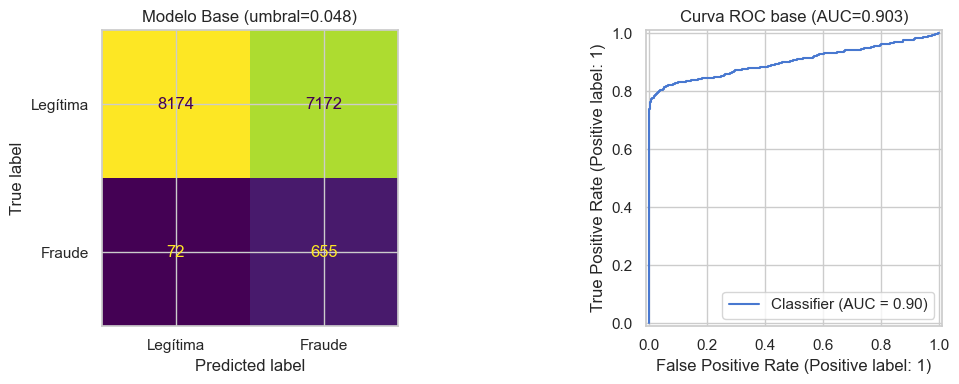

In [57]:
# buscando un umbral donde recall >= 90%
idx_90 = np.where(recall_arr >= 0.90)[0]
if len(idx_90) > 0:
    thresh_90 = thresholds_arr[idx_90[-1]]
else:
    thresh_90 = 0.5

y_pred_90 = (y_proba_base >= thresh_90).astype(int)
TP = ((y_pred_90 == 1) & (y_test == 1)).sum()
FP = ((y_pred_90 == 1) & (y_test == 0)).sum()
FN = ((y_pred_90 == 0) & (y_test == 1)).sum()

recall_actual  = TP / (TP + FN) if (TP + FN) > 0 else 0
fp_ratio       = FP / (TP + FP) if (TP + FP) > 0 else 0

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_90, display_labels=['Legítima','Fraude'],
    ax=axes[0], colorbar=False)
axes[0].set_title(f'Modelo Base (umbral={thresh_90:.3f})')
RocCurveDisplay.from_predictions(y_test, y_proba_base, ax=axes[1])
axes[1].set_title(f'Curva ROC base (AUC={roc_auc_score(y_test, y_proba_base):.3f})')
plt.tight_layout()
plt.show()

In [58]:
print('=== Modelo Base — Test (Junio 2025) ===')
print(f'AUC-ROC:                {roc_auc_score(y_test, y_proba_base):.4f}')
print(f'Umbral @90% recall:     {thresh_90:.4f}')
print(f'Recall alcanzado:       {recall_actual:.2%}')
print(f'Ratio FP (=FP/TP+FP):   {fp_ratio:.4f}') # métrica que quiero optimizar
print(f'TP={TP}  FP={FP}  FN={FN}')

=== Modelo Base — Test (Junio 2025) ===
AUC-ROC:                0.9026
Umbral @90% recall:     0.0477
Recall alcanzado:       90.10%
Ratio FP (=FP/TP+FP):   0.9163
TP=655  FP=7172  FN=72
